# Banking Loan Aprooval 

## Importing necessary libraries 

In [1]:
import pandas as pd
import numpy as np

# Visualization (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [2]:
df=pd.read_csv("credit_risk_dataset.csv")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [4]:
df.shape

(32581, 12)

- Observation :
    Dataset have 32581 Rows and 12 columns

In [6]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [11]:
df['loan_status'].nunique()

2

In [12]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [17]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

- observation :
     - Here column person_emp_length and column loan_int_rate have some missing values.
     - we are treating the missing values help of median.


In [18]:
df['person_emp_length'].fillna(df['person_emp_length'].median(),inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(),inplace=True)

In [20]:
df.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [23]:
df.duplicated().sum()

165

- Observation
    - Dataset have 165 Duplicates records.
    - Here we are removing the Duplicates records.

In [26]:
df=df.drop_duplicates()
df.duplicated().sum()

0

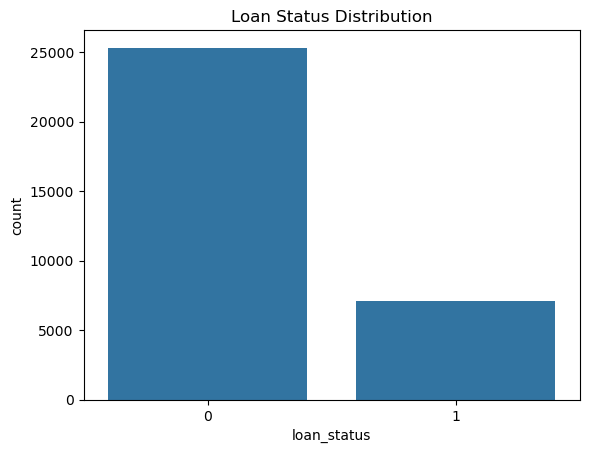

In [27]:
sns.countplot(x='loan_status', data = df)
plt.title("Loan Status Distribution")
plt.show()

- Observation
    - Target Variable : Loan_status
    - 0 : 25473
    - 1 : 7108
    - So the Data is imbalanced

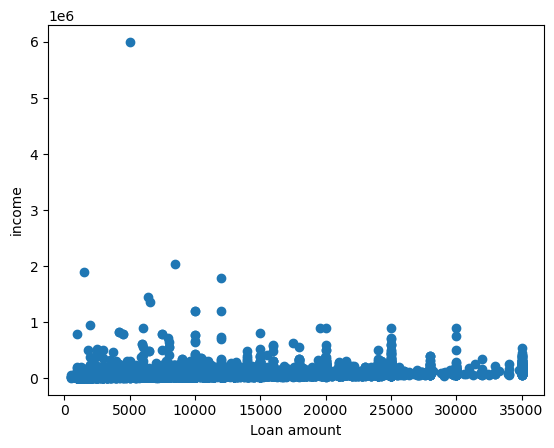

In [28]:
plt.scatter(df['loan_amnt'],df['person_income'])
plt.xlabel("Loan amount")
plt.ylabel("income")
plt.show()

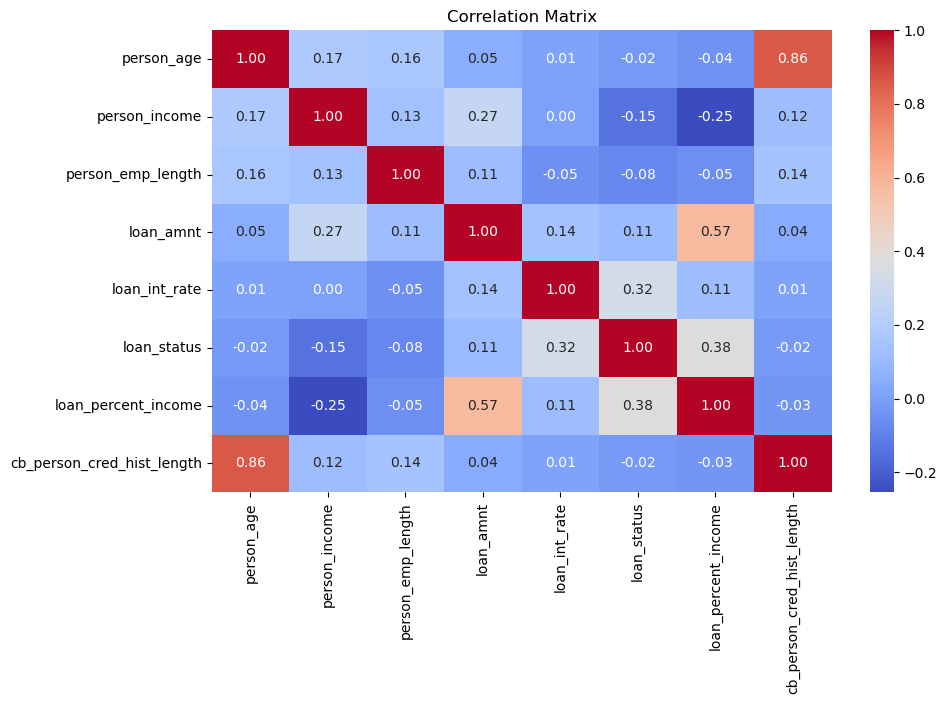

In [30]:

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


## Data Preparation

### Encoding the categorical variable 

In [31]:
le=LabelEncoder()
df['person_home_ownership']= le.fit_transform(df['person_home_ownership'])
df['loan_intent']= le.fit_transform(df['loan_intent'])
df['loan_grade'] = le.fit_transform (df['loan_grade'])
df['cb_person_default_on_file']= le.fit_transform(df['cb_person_default_on_file'])

In [32]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,123.0,4,3,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,2,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,2,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,2,35000,14.27,1,0.55,1,4


### Separate feature and target

In [34]:
x=df.drop('loan_status',axis=1)
y=df['loan_status']

In [36]:
x.head(2)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,3,123.0,4,3,35000,16.02,0.59,1,3
1,21,9600,2,5.0,1,1,1000,11.14,0.10,0,2


In [37]:
y.head(2)

0    1
1    0
Name: loan_status, dtype: int64

### Train Test Split

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x,y , test_size=0.2, random_state=42,)

In [39]:
x_train.shape

(25932, 11)

In [40]:
x_test.shape

(6484, 11)

### Scaling the data

In [43]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)


## Note:- The data is imbalance.
    - Here we balance the data using SMOTE.
    

## Applying SMOTE for imbalance data

In [45]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state =24)
x_train_res, y_train_res = smote.fit_resample(x_train_scaled ,y_train)

- Observation :-
    - Train model on x_train_res, y_train_res

- evaluation on
- X_test_scaled

## Building model

- KNN Classification 

In [49]:
Knn = KNeighborsClassifier()
Knn.fit(x_train_res, y_train_res)

KNeighborsClassifier()

- Lostistic classification

In [50]:
lr = LogisticRegression()
lr.fit(x_train_res, y_train_res)

LogisticRegression()

- SVM classification

In [53]:
svm = SVC()
svm.fit(x_train_res,y_train_res)

SVC()

- Decision Tree Classification

In [54]:
dt= DecisionTreeClassifier()
dt.fit(x_train_res, y_train_res)

DecisionTreeClassifier()

- Random Forest Classification

In [55]:
rf=RandomForestClassifier()
rf.fit(x_train_res, y_train_res)

RandomForestClassifier()

## Evaluation matrix

- KNN Model

In [56]:
y_pred_knn =Knn.predict(x_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8018198642813078
[[4120  953]
 [ 332 1079]]
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      5073
           1       0.53      0.76      0.63      1411

    accuracy                           0.80      6484
   macro avg       0.73      0.79      0.75      6484
weighted avg       0.84      0.80      0.81      6484



- Logistics Regression 

In [57]:
y_pred_lr =lr.predict(x_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7873226403454657
[[4019 1054]
 [ 325 1086]]
              precision    recall  f1-score   support

           0       0.93      0.79      0.85      5073
           1       0.51      0.77      0.61      1411

    accuracy                           0.79      6484
   macro avg       0.72      0.78      0.73      6484
weighted avg       0.83      0.79      0.80      6484



- SVC 

In [59]:
y_pred_svc =svm.predict(x_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svc))
print(confusion_matrix(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

SVM Accuracy: 0.8602714373843307
[[4525  548]
 [ 358 1053]]
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      5073
           1       0.66      0.75      0.70      1411

    accuracy                           0.86      6484
   macro avg       0.79      0.82      0.80      6484
weighted avg       0.87      0.86      0.86      6484



- DT Classifier

In [60]:
y_pred_dt =dt.predict(x_test_scaled)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.871838371375694
[[4590  483]
 [ 348 1063]]
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      5073
           1       0.69      0.75      0.72      1411

    accuracy                           0.87      6484
   macro avg       0.81      0.83      0.82      6484
weighted avg       0.88      0.87      0.87      6484



- Random Forest Classification

In [61]:
y_pred_rf =rf.predict(x_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9290561381863047
[[5004   69]
 [ 391 1020]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5073
           1       0.94      0.72      0.82      1411

    accuracy                           0.93      6484
   macro avg       0.93      0.85      0.89      6484
weighted avg       0.93      0.93      0.93      6484



### Observation of the evaluation matrix results: 

| Model          | Accuracy | F1 (class 1) |
|---------------|----------|--------------|
| KNN           | 0.80     | 0.63         |
| Logistic      | 0.79     | 0.61         |
| SVM           | 0.86     | 0.70         |
| Decision Tree | 0.87     | 0.72         |
| Random Forest | 0.93     | 0.82         |


- 1. After evaluating all the models, **Random Forest achieved the highest accuracy** and F1-score.

- 2. This indicates that Random Forest is the most suitable model for predicting loan default risk.

- 3. Decision Tree and **Support Vector Machine (SVM)** also delivered strong and competitive performance.

- 4. In comparison, Logistic Regression and KNN showed relatively lower performance than the other models.

# Save Model as .pkl File

In [63]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(sc, "scaler.pkl")

['scaler.pkl']

- pkl file is saved now.
- To increase the accuracy of rf we trying hyper parameter tunning.

## Hyper parameter tunning

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf2 = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf2,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(x_train_res, y_train_res)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [66]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(x_test_scaled)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9309068476249229
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5073
           1       0.95      0.72      0.82      1411

    accuracy                           0.93      6484
   macro avg       0.94      0.86      0.89      6484
weighted avg       0.93      0.93      0.93      6484

